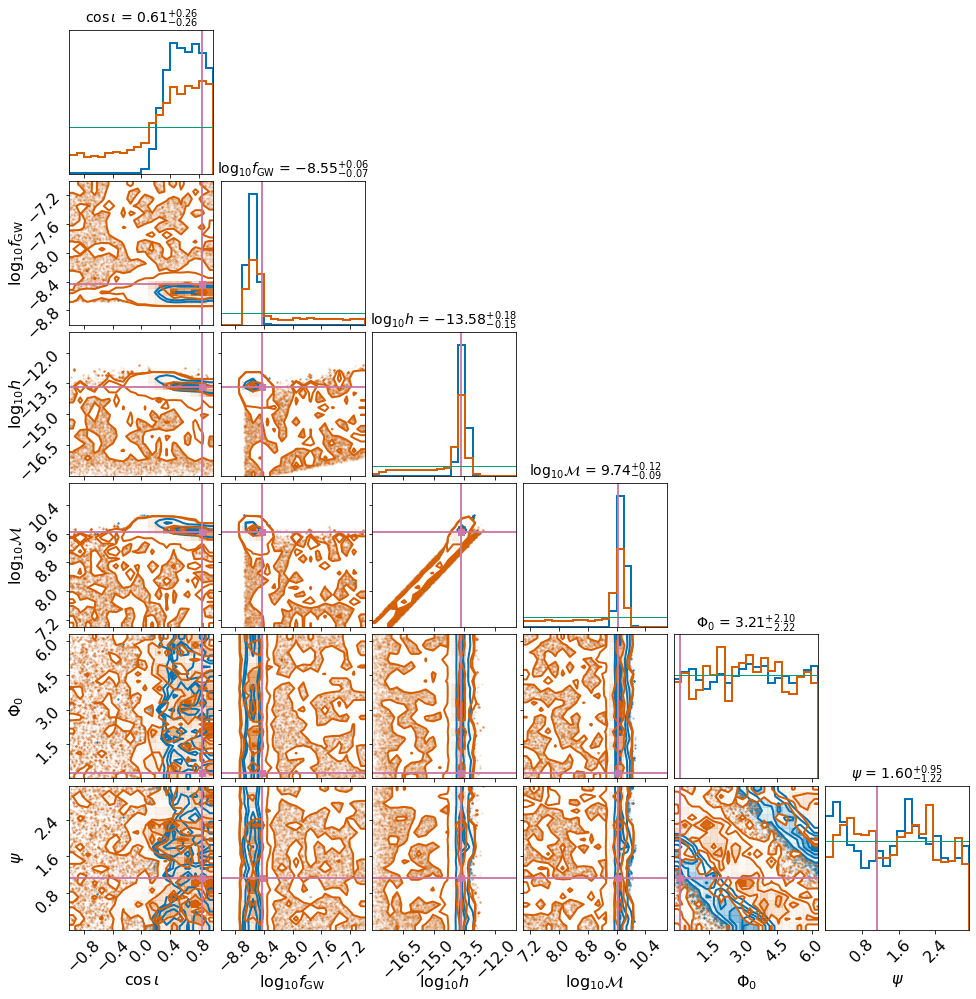

In [5]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":     0.8412486994612669,
    "0_log10_fgw":   np.log10(3.7e-9),            # fgw
    "0_log10_h":     -13.668773493298787,         # strain
    "0_log10_mc":    np.log10(4.3e9),             # chirp mass
    "0_phase0":      0.24434609527920614,
    "0_psi":         1.1187560505283651,
}

# ============================================================
# Final desired plotting order:
# cosi → fgw → strain → mc → phase0 → psi
# ============================================================
qc_keys = [
    "0_cos_inc",
    "0_log10_fgw",
    "0_log10_h",
    "0_log10_mc",
    "0_phase0",
    "0_psi",
]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} f_{\rm GW}$",
    r"$\log_{10} h$",
    r"$\log_{10}\mathcal{M}$",
    r"$\Phi_0$",
    r"$\psi$",
]

# ============================================================
# 2. Priors (green lines)
# ============================================================
def add_priors(ax, i):

    if i == 0:      # cos(iota)
        X = np.linspace(-1, 1)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 1:    # log10 fgw
        X = np.linspace(-9, -7)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 2:    # log10 h
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:    # log10 Mc
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 4:    # phase0
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, 0*X + 1/(2*np.pi), color="#009E73", lw=1)

    elif i == 5:    # psi
        X = np.linspace(0, np.pi)
        ax.plot(X, 0*X + 1/np.pi, color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW (UNCHANGED)
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_broad_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([qc_samples[:, qc_params.index(k)] for k in qc_keys])


# ============================================================
# 4. Load Enterprise (same file, same params)
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "ent_files/D2_det_varyfgw_core_single.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

# ------------------------------------------------------------
# Extract Enterprise parameters (DO NOT USE log10_h0)
# ------------------------------------------------------------
idx_cos_inc  = e_params.index("cos_inc")
idx_log10_f  = e_params.index("log10_fgw")
idx_log10_mc = e_params.index("log10_mc")
idx_phase0   = e_params.index("phase0")
idx_psi      = e_params.index("psi")

cos_inc_ent  = e_samples[:, idx_cos_inc]
log10_f_ent  = e_samples[:, idx_log10_f]
log10_mc_ent = e_samples[:, idx_log10_mc]
phase0_ent   = e_samples[:, idx_phase0]
psi_ent      = e_samples[:, idx_psi]

# ============================================================
# 5. ENTERPRISE → PHYSICAL, DIMENSIONLESS STRAIN h0
# ============================================================
# Distance (fixed, same as QuickCW)
D_MPC = 75.400
MPC2M = 3.085677581491367e22
dL_m  = D_MPC * MPC2M

# Physical constants
G = 6.67430e-11
c = 2.99792458e8
M_sun = 1.98840987e30

# Convert parameters
mc_solar = 10**log10_mc_ent
fgw      = 10**log10_f_ent

# Convert to time units (seconds)
mc_time = mc_solar * M_sun * G / c**3
dL_time = dL_m / c    # <<< CRITICAL FIX

# Dimensionless strain
h0_ent = (
    2
    * mc_time**(5/3)
    * (np.pi * fgw)**(2/3)
    / dL_time
)

log10_h0_ent = np.log10(h0_ent)

# ------------------------------------------------------------
# Final Enterprise plotting array (same order as QuickCW)
# ------------------------------------------------------------
ent_plot = np.column_stack([
    cos_inc_ent,
    log10_f_ent,
    log10_h0_ent,
    log10_mc_ent,
    phase0_ent,
    psi_ent,
])


# ============================================================
# 6. Fixed axis ranges (UNCHANGED)
# ============================================================
ranges = [
    (-1, 1),
    (-9, -7),
    (-18, -11),
    (7, 11),
    (0, 2*np.pi),
    (0, np.pi),
]


# ============================================================
# 7. Fonts + colors
# ============================================================
plt.rcParams["font.size"] = 16

c_qc    = "#0072B2"
c_ent   = "#D55E00"
c_truth = "#CC79A7"
c_prior = "#009E73"


# ============================================================
# 8. QuickCW corner plot
# ============================================================
fig = corner.corner(
    qc_plot,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    range=ranges,
    show_titles=True,
    hist_kwargs=dict(density=True, color=c_qc, linewidth=2.0),
    contour_kwargs=dict(colors=[c_qc], linewidths=2.0),
    label_kwargs={"fontsize": 16},
    fill_contours=False,
)

# ============================================================
# 9. Overlay Enterprise
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_ent,
    range=ranges,
    show_titles=False,
    hist_kwargs=dict(density=True, color=c_ent, linewidth=2.0),
    contour_kwargs=dict(colors=[c_ent], linewidths=2.0),
    fill_contours=False,
)

# ============================================================
# 10. Priors
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

# ============================================================
# 11. Formatting
# ============================================================
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=16)

plt.show()


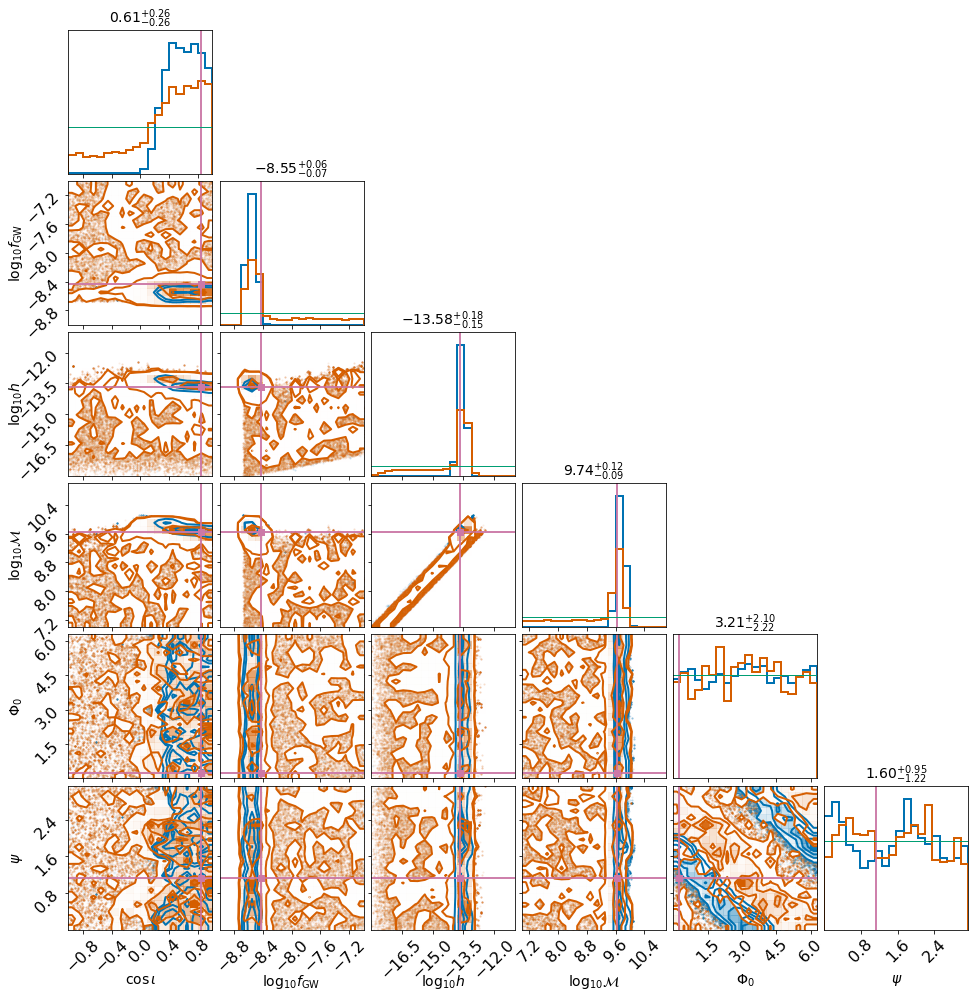

In [1]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":     0.8412486994612669,
    "0_log10_fgw":   np.log10(3.7e-9),
    "0_log10_h":     -13.668773493298787,
    "0_log10_mc":    np.log10(4.3e9),
    "0_phase0":      0.24434609527920614,
    "0_psi":         1.1187560505283651,
}

# ============================================================
# Desired order:
# cos i → fgw → strain → mc → phase0 → psi
# ============================================================
qc_keys = [
    "0_cos_inc",
    "0_log10_fgw",
    "0_log10_h",
    "0_log10_mc",
    "0_phase0",
    "0_psi",
]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} f_{\rm GW}$",
    r"$\log_{10} h$",
    r"$\log_{10}\mathcal{M}$",
    r"$\Phi_0$",
    r"$\psi$",
]

# ============================================================
# 2. Priors (green lines)
# ============================================================
def add_priors(ax, i):

    if i == 0:      # cos(i) uniform in [-1,1]
        X = np.linspace(-1, 1)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 1:    # log10 fgw ∈ [-9,-7] → uniform
        X = np.linspace(-9, -7)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 2:    # log10 h uniform in chosen bounds
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:    # log10 Mc uniform
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 4:    # phase0 ∈ [0,2π]
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, 0*X + 1/(2*np.pi), color="#009E73", lw=1)

    elif i == 5:    # psi ∈ [0,π]
        X = np.linspace(0, np.pi)
        ax.plot(X, 0*X + 1/np.pi, color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_broad_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([qc_samples[:, qc_params.index(k)] for k in qc_keys])


# ============================================================
# 4. Load Enterprise
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "ent_files/D2_det_varyfgw_core_single.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

ent_map = {
    "0_cos_inc":    "cos_inc",
    "0_log10_fgw":  "log10_fgw",
    "0_log10_h":    "log10_h0",
    "0_log10_mc":   "log10_mc",
    "0_phase0":     "phase0",
    "0_psi":        "psi",
}

ent_plot = np.column_stack([e_samples[:, e_params.index(ent_map[k])]
                            for k in qc_keys])


# ============================================================
# 5. Define fixed axis ranges for corner plot
# ============================================================
ranges = [
    (-1, 1),          # cos i
    (-9, -7),         # log10 fgw → fixed, centered
    (-18,-11),             # log10 h auto
    (7,11),             # log10 Mc auto
    (0, 2*np.pi),     # phase0
    (0, np.pi),       # psi
]


# ============================================================
# 6. Fonts
# ============================================================
plt.rcParams["font.size"] = 16
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

# Okabe–Ito colors (colorblind-safe)
c_qc    = "#0072B2"  # blue
c_ent   = "#D55E00"  # vermillion
c_truth = "#CC79A7"  # purple
c_prior = "#009E73"  # green


# ============================================================
# 7. Main corner plot (QuickCW)
# ============================================================
fig = corner.corner(
    qc_plot,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    range=ranges,
    show_titles=True,
    hist_kwargs=dict(density=True, color=c_qc, linewidth=2.0),
    contour_kwargs=dict(colors=[c_qc], linewidths=2.0),
    label_kwargs={"fontsize": 16},
    fill_contours=False,
)

# ============================================================
# 8. Overlay Enterprise
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_ent,
    range=ranges,
    show_titles=False,
    hist_kwargs=dict(density=True, color=c_ent, linewidth=2.0),
    contour_kwargs=dict(colors=[c_ent], linewidths=2.0),
    fill_contours=False,
)

# ============================================================
# 9. Priors on diagonal
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

# ============================================================
# 10. Format final figure
# ============================================================
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=16)

plt.show()


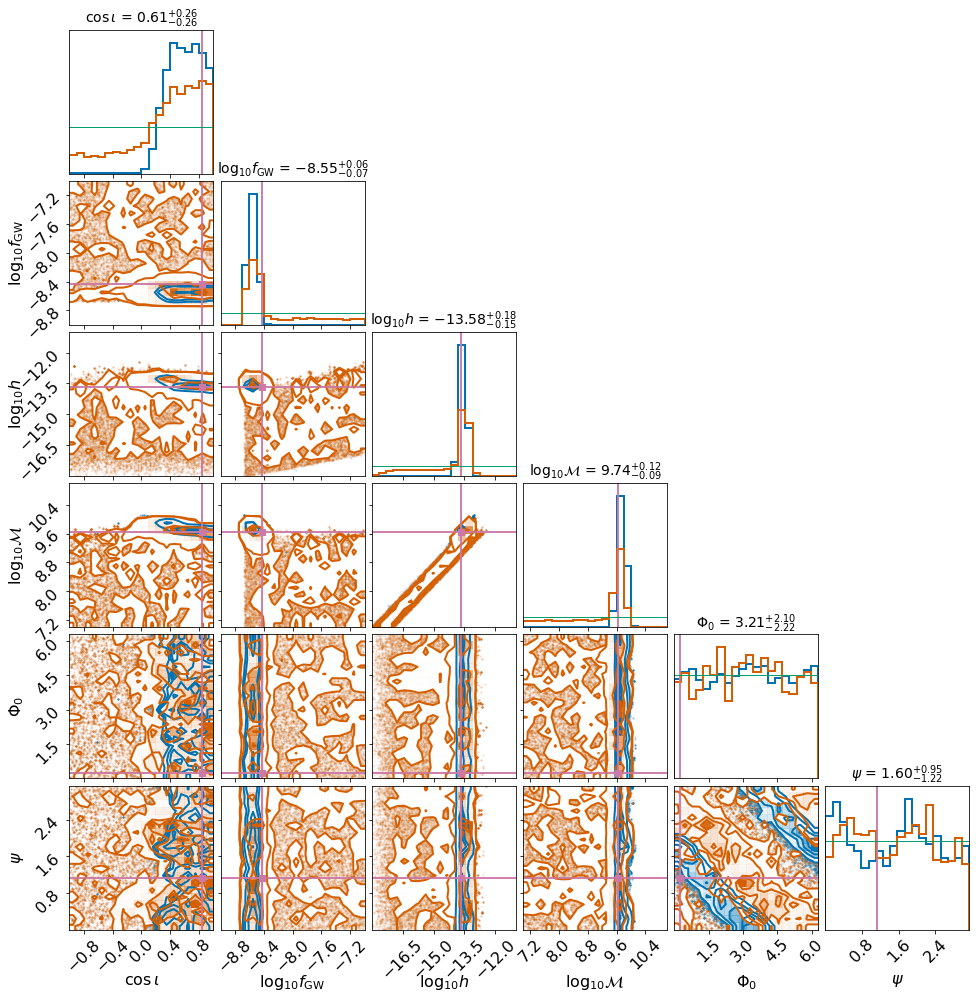

In [2]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import h5py
import matplotlib.pyplot as plt
import corner

# ============================================================
# 1. Truth values (QuickCW naming)
# ============================================================
truth = {
    "0_cos_inc":     0.8412486994612669,
    "0_log10_fgw":   np.log10(3.7e-9),            # fgw
    "0_log10_h":     -13.668773493298787,         # strain
    "0_log10_mc":    np.log10(4.3e9),             # chirp mass
    "0_phase0":      0.24434609527920614,
    "0_psi":         1.1187560505283651,
}

# ============================================================
# Final desired plotting order:
# cosi → fgw → strain → mc → phase0 → psi
# ============================================================
qc_keys = [
    "0_cos_inc",
    "0_log10_fgw",
    "0_log10_h",
    "0_log10_mc",
    "0_phase0",
    "0_psi",
]

labels = [
    r"$\cos\iota$",
    r"$\log_{10} f_{\rm GW}$",
    r"$\log_{10} h$",
    r"$\log_{10}\mathcal{M}$",
    r"$\Phi_0$",
    r"$\psi$",
]

# ============================================================
# 2. Priors (green lines)
# ============================================================
def add_priors(ax, i):

    if i == 0:      # cos(iota) ∈ [-1,1]
        X = np.linspace(-1,1)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 1:    # log10 fgw ∈ [-9,-7]
        X = np.linspace(-9, -7)
        ax.plot(X, 0*X + 1/2, color="#009E73", lw=1)

    elif i == 2:    # log10 h uniform
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 3:    # log10 Mc uniform
        xl, xr = ax.get_xlim()
        X = np.linspace(xl, xr)
        ax.plot(X, 0*X + 1/(xr-xl), color="#009E73", lw=1)

    elif i == 4:    # phase0 ∈ [0,2π]
        X = np.linspace(0, 2*np.pi)
        ax.plot(X, 0*X + 1/(2*np.pi), color="#009E73", lw=1)

    elif i == 5:    # psi ∈ [0,π]
        X = np.linspace(0, np.pi)
        ax.plot(X, 0*X + 1/np.pi, color="#009E73", lw=1)


# ============================================================
# 3. Load QuickCW
# ============================================================
quickcw_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "G2D2_broad_detect_dLmasked_75.400Mpc.h5"
)

with h5py.File(quickcw_file, "r") as f:
    qc_samples = f["samples_masked"][...]
    qc_params  = [x.decode("utf-8") for x in f["par_names"][...]]

qc_plot = np.column_stack([qc_samples[:, qc_params.index(k)] for k in qc_keys])


# ============================================================
# 4. Load Enterprise
# ============================================================
enterprise_file = (
    "/scratch/na00078/projects/IPTA_MDC2/h5_files/dl_masked/"
    "ent_files/D2_det_varyfgw_core_single.h5"
)

with h5py.File(enterprise_file, "r") as f:
    e_samples = f["chain"][...]
    e_params  = [p.decode("utf-8") for p in f["params"][...]]
    burn      = f["metadata/burn"][()]

e_samples = e_samples[burn:, :]

ent_map = {
    "0_cos_inc":    "cos_inc",
    "0_log10_fgw":  "log10_fgw",
    "0_log10_h":    "log10_h0",
    "0_log10_mc":   "log10_mc",
    "0_phase0":     "phase0",
    "0_psi":        "psi",
}

ent_plot = np.column_stack([e_samples[:, e_params.index(ent_map[k])]
                            for k in qc_keys])


# ============================================================
# 5. Fixed axis ranges for cleaner plots
# ============================================================
ranges = [
    (-1, 1),          # cos i
    (-9, -7),         # log10 fgw
    (-18, -11),       # log10 h
    (7, 11),          # log10 Mc
    (0, 2*np.pi),     # phase0
    (0, np.pi),       # psi
]


# ============================================================
# 6. Fonts + colors
# ============================================================
plt.rcParams["font.size"] = 16

c_qc    = "#0072B2"  # blue
c_ent   = "#D55E00"  # orange
c_truth = "#CC79A7"  # magenta
c_prior = "#009E73"  # green


# ============================================================
# 7. QuickCW corner plot
# ============================================================
fig = corner.corner(
    qc_plot,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_qc,
    range=ranges,
    show_titles=True,
    hist_kwargs=dict(density=True, color=c_qc, linewidth=2.0),
    contour_kwargs=dict(colors=[c_qc], linewidths=2.0),
    label_kwargs={"fontsize": 16},
    fill_contours=False,
)

# ============================================================
# 8. Overlay Enterprise
# ============================================================
corner.corner(
    ent_plot,
    fig=fig,
    labels=labels,
    truths=[truth[k] for k in qc_keys],
    truth_color=c_truth,
    color=c_ent,
    range=ranges,
    show_titles=False,
    hist_kwargs=dict(density=True, color=c_ent, linewidth=2.0),
    contour_kwargs=dict(colors=[c_ent], linewidths=2.0),
    fill_contours=False,
)

# ============================================================
# 9. Priors on diagonal
# ============================================================
axes = np.array(fig.axes).reshape(len(labels), len(labels))
for i in range(len(labels)):
    add_priors(axes[i, i], i)

# ============================================================
# 10. Formatting
# ============================================================
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=16)

plt.show()


In [3]:
from enterprise_extensions import model_utils
# amplitude column in qc_plot = column index 3 if you included fgw
# but in your 5-parameter version, log10_h was index=2
qc_amp = qc_plot[:, qc_keys.index("0_log10_h")]

qc_BF, qc_BF_err = model_utils.bayes_fac(
    samples=qc_amp,
    logAmax=-11
)

print(f"QuickCW SD Bayes Factor: {qc_BF:.4f} ± {qc_BF_err:.4f}")

ent_amp = ent_plot[:, qc_keys.index("0_log10_h")]

ent_BF, ent_BF_err = model_utils.bayes_fac(
    samples=ent_amp,
    logAmax=-11
)

print(f"Enterprise SD Bayes Factor: {ent_BF:.4f} ± {ent_BF_err:.4f}")


QuickCW SD Bayes Factor: nan ± nan
Enterprise SD Bayes Factor: nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/scipy/stats/_ksstats.py:74: RuntimeWarning: invalid value encountered in ldexp
  _EP128 = np.ldexp(np.longdouble(1), _E128)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: inva

## Corner Plots

In [4]:
print(BF_err_arr[0:10])

NameError: name 'BF_err_arr' is not defined

In [ ]:
print(np.log10(3.7e-9))